In [ ]:
idx = []
cs = []
for i, c in enumerate("hello world"):
    idx.append(i)
    cs.append(c)
idx, cs

In [ ]:
chr_idx = {i:c for i, c in zip(idx, cs) if i %3 == 0}
chr_idx

# Day3 · 블록3 · 센서 로그 파싱 & 시각화 자동화 실습

> **강의자료**: `강의자료/03.03.Python-Sensor-Log.md`

로봇이 운행 중 생성한 텍스트 로그 파일에서 센서 데이터를 추출·분석·시각화·자동화하는
전체 파이프라인을 4단계로 구현합니다.

| Part | 주제 |
|------|------|
| Part 1 | 실습 개요 및 목표 |
| Part 2 | Step 1 — JSON 설정 로드 & 정규표현식 |
| Part 3 | Step 2 — Sensor 클래스 통합 & 로그 파싱 |
| Part 4 | Step 3 — NumPy 이상값 탐지 & Matplotlib 시각화 |
| Part 5 | Step 4 — 멀티스레딩 자동화 |
| Part 6 | Troubleshooting & 심화 미션 |

---
## Part 1: 실습 개요 및 목표

### 실습 목표 — 로봇 로그 분석 자동화 시스템 구축

- `config.json`으로 임계치(Threshold) 설정을 관리하는 방법
- 정규표현식(Regex)으로 비정형 텍스트에서 데이터를 추출하는 방법
- **NumPy**로 이상값(Anomaly)을 탐지하고 **Matplotlib**으로 시각화하는 방법
- **멀티스레딩**으로 분석 작업을 백그라운드에서 자동화하는 방법

### 만들어지는 결과물

- `sensor_report.png` — 이상값이 표시된 센서 데이터 그래프
- 메인 루프와 분석 스레드가 동시에 동작하는 자동화 프로그램

### 4단계 구현 순서

| 단계 | 내용 | 핵심 기술 |
|------|------|-----------|
| 준비 | 설정 파일(`json`) 및 샘플 로그 파일(`txt`) 생성 | `json`, 파일 I/O |
| Step 1 | JSON 설정 파일 로드 및 정규표현식 패턴 설계 | `json`, `re` |
| Step 2 | `Sensor` 클래스 통합 및 로그 데이터 파싱 구현 | OOP, `re` |
| Step 3 | NumPy 이상값 탐지 및 Matplotlib 시각화 | `numpy`, `matplotlib` |
| Step 4 | Threading 자동화 및 최종 통합 | `threading` |

---
## Part 2: Step 1 — JSON 설정 로드 & 정규표현식

### 개념 — JSON 설정 관리

하드코딩 대신 외부 파일에서 설정을 읽어오는 구조를 사용합니다.

**왜 JSON으로 설정을 관리하는가?**
- 코드를 수정하지 않고 임계치 값만 바꿀 수 있음
- 로봇 종류나 환경마다 다른 설정 파일을 사용할 수 있음
- 팀원과 설정값을 공유·버전 관리할 수 있음

**config.json 파일 구조 예시**

```json
{
    "sensor_name": "Lidar_1",
    "threshold": 80.5
}
```

### 개념 — 정규표현식(Regex) 패턴 설계

비정형 텍스트 로그에서 데이터를 추출하는 '규칙'입니다.

**로그 파일 한 줄 예시**
```
[2024-05-20 12:00:01] INFO: Sensor value = 45.2
```

**정규표현식 패턴 분석**

| 패턴 조각 | 의미 | 추출 대상 |
|-----------|------|-----------|
| `\[(?P<timestamp>.*?)\]` | `[...]` 안의 문자열 캡처 | 타임스탬프 |
| `.*?` | 임의의 문자열 (최소 매칭) | `INFO:` 부분 스킵 |
| `value = ` | 리터럴 문자열 | 구분자 |
| `(?P<value>\d+\.\d+)` | 소수점 숫자 캡처 | 센서 값 |

In [ ]:
import json
import re

# 1. 설정 파일 읽기 (임계치 설정)
def load_config():
    # JSON 파일 생성 및 로드
    config_data = {"sensor_name": "Lidar_1", "threshold": 80.5}
    with open('config.json', 'w') as f:
        json.dump(config_data, f)

    with open('config.json', 'r') as f:
        return json.load(f)



config = load_config()
print(f"설정 로드 완료: 임계치 {config['threshold']}")

---
## Part 3: Step 2 — Sensor 클래스 통합 & 로그 파싱

### 개념 — OOP로 센서 데이터 구조화

Day 2에서 배운 클래스를 활용하여 로봇 하드웨어를 소프트웨어로 추상화합니다.

**Sensor 클래스의 역할**
- 센서 이름, 측정값 목록, 타임스탬프 목록을 하나의 객체로 관리
- `add_reading()` 메서드로 파싱된 데이터를 순서대로 추가

**파싱 흐름**
```
로그 파일 한 줄 읽기
      ↓
re.search()로 패턴 매칭
      ↓
match.group()으로 데이터 추출
      ↓
sensor_obj.add_reading()으로 저장
```

In [2]:
import numpy as np

# 2. 정규표현식 정의
# 로그 형식: "[2024-05-20 12:00:01] INFO: Sensor value = 45.2"
log_pattern = r"\[(?P<timestamp>.*?)\] .*? value = (?P<value>\d+\.\d+)"

# Day2에서 만든 Sensor 클래스 (간략화 버전)
class Sensor:
    def __init__(self, name):
        self.name = name
        self.data = []
        self.timestamps = []

    def add_reading(self, timestamp, value):
        self.timestamps.append(timestamp)
        self.data.append(float(value))

def parse_logs(file_path, sensor_obj):
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(log_pattern, line)
            if match:
                # 정규표현식 그룹에서 데이터 추출
                ts = match.group('timestamp')
                val = match.group('value')
                sensor_obj.add_reading(ts, val)

### 핵심 포인트 — `if match:` 가 중요한 이유

`re.search()`가 패턴을 찾지 못하면 `None`을 반환합니다.

**잘못된 코드 (AttributeError 발생)**
```python
match = re.search(log_pattern, line)
ts = match.group('timestamp')  # ← match가 None이면 오류!
```

**올바른 코드 (항상 None 체크)**
```python
match = re.search(log_pattern, line)
if match:                           # ← None 여부 먼저 확인
    ts = match.group('timestamp')
    val = match.group('value')
```

**규칙:** `re.search()` / `re.match()` 결과는 항상 `if match:` 로 확인 후 사용

### TODO: parse_logs 직접 구현해 보기

아래 셀에서 `parse_logs_student()` 함수를 직접 작성해 보세요.
- `re.search()`로 각 줄에서 패턴 매칭
- `if match:` 로 None 체크
- `match.group()`으로 타임스탬프·값 추출
- `sensor_obj.add_reading()`으로 저장

In [6]:
import re
import datetime

log_pattern = r"\[(?P<timestamp>.*?)\] .*? value = (?P<value>\d+\.\d+)"

# 샘플 로그 파일 생성
sensor = Sensor("my sensor")
for i in range(100):
    sensor.add_reading(str(datetime.datetime.now()), str(50 + np.random.rand() * 50))

with open("my_sensor_log.txt", "w") as f:
    for t, v in zip(sensor.timestamps, sensor.data):
        f.write(f"[{t}] INFO: Sensor value = {v}\n")

def parse_logs_student(file_path, sensor_obj):
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(log_pattern, line)
            if match:
                ts = match.group('timestamp')
                val = match.group('value')
                sensor_obj.add_reading(ts, val)

# 테스트
student_sensor = Sensor("student_sensor")
parse_logs_student("my_sensor_log.txt", student_sensor)
print(f"파싱 완료: {len(student_sensor.data)}개 읽음")
print(f"첫 번째 값: {student_sensor.data[0]:.4f} at {student_sensor.timestamps[0]}")

파싱 완료: 100개 읽음
첫 번째 값: 83.8279 at 2026-04-22 16:24:07.431619


---
## Part 4: Step 3 — NumPy 이상값 탐지 & Matplotlib 시각화

### 개념 — NumPy 불리언 인덱싱으로 이상값 탐지

리스트 대신 NumPy 배열을 사용하면 벡터화 연산으로 이상값을 한 번에 탐지할 수 있습니다.

**Python 리스트 방식 (비효율)**
```python
anomalies = [v for v in data if v > threshold]  # 루프 필요
```

**NumPy 방식 (벡터화 연산)**
```python
values = np.array(sensor_obj.data)   # 배열로 변환
anomalies = values > threshold        # 불리언 배열 생성
anomaly_indices = np.where(anomalies) # 이상값 인덱스 추출
```

`np.where(condition)` → 조건이 `True`인 인덱스를 튜플로 반환

In [8]:
import matplotlib.pyplot as plt

def analyze_and_plot(sensor_obj, threshold):
    # 리스트를 NumPy 배열로 변환 (고속 연산 가능)
    values = np.array(sensor_obj.data)

    # 이상값 탐지: NumPy 불리언 인덱싱 활용
    anomalies = values > threshold
    anomaly_indices = np.where(anomalies)

    # 그래프 그리기
    plt.figure(figsize=(10, 5))
    plt.plot(sensor_obj.data, label='Sensor Value', color='blue')

    # 이상값 표시 (붉은 점)
    if len(anomaly_indices[0]) > 0:
        plt.scatter(anomaly_indices, values[anomaly_indices],
                    color='red', label='Anomaly')

    plt.axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    plt.title(f"Robot {sensor_obj.name} Data Analysis")
    plt.xlabel("Time Steps")
    plt.ylabel("Value")
    plt.legend()

    # 결과 저장
    plt.savefig('sensor_report.png')
    plt.show()
    print(f"분석 완료: 이상값 {len(anomaly_indices[0])}개 발견. 'sensor_report.png' 저장됨.")

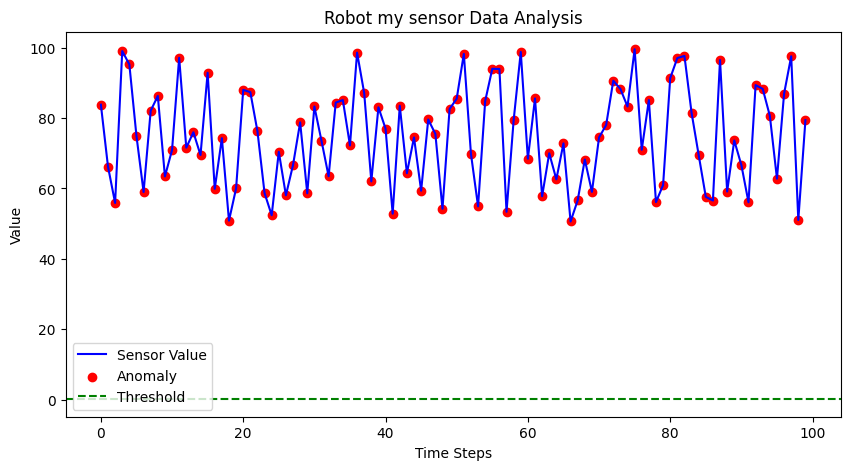

분석 완료: 이상값 100개 발견. 'sensor_report.png' 저장됨.


In [9]:
analyze_and_plot(sensor, 0.1)

### 시각화 결과 해석

`sensor_report.png` 에서 확인할 수 있는 정보:

- **파란 선 (Sensor Value):** 시간 흐름에 따른 전체 센서 값 변화
- **초록 점선 (Threshold):** 설정 파일에서 읽어온 임계치 선
    - `plt.axhline()` — 가로 기준선 그리기
- **붉은 점 (Anomaly):** 임계치를 초과한 이상값 위치
    - `plt.scatter()` — 산점도로 특정 지점 강조 표시

**`plt.savefig()` vs `plt.show()`**
- `savefig()`: 파일로 저장 (스레드 안에서도 안전)
- `show()`: 화면에 창을 표시 (반드시 메인 스레드에서 실행)

### TODO: analyze_and_plot 직접 구현해 보기

아래 셀에서 `analyze_and_plot_student()` 함수를 직접 작성해 보세요.
- `np.array()`로 데이터 변환
- `np.where()`로 이상값 인덱스 추출
- `plt.plot()`, `plt.scatter()`, `plt.axhline()`으로 그래프 그리기
- `plt.savefig()`로 파일 저장

In [ ]:
def analyze_and_plot_student(sensor_obj, threshold):
    values = np.array(sensor_obj.data)
    anomalies = values > threshold
    anomaly_indices = np.where(anomalies)

    plt.figure(figsize=(10, 5))
    plt.plot(sensor_obj.data, label='Sensor Value', color='blue')

    if len(anomaly_indices[0]) > 0:
        plt.scatter(anomaly_indices, values[anomaly_indices],
                    color='red', label='Anomaly')

    plt.axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    plt.title(f"Robot {sensor_obj.name} Data Analysis")
    plt.xlabel("Time Steps")
    plt.ylabel("Value")
    plt.legend()

    plt.savefig('sensor_report.png')
    plt.show()
    print(f"분석 완료: 이상값 {len(anomaly_indices[0])}개 발견. 'sensor_report.png' 저장됨.")

---
## Part 5: Step 4 — 멀티스레딩 자동화

### 개념 — 왜 멀티스레딩이 필요한가?

로봇은 로그 분석과 주행 제어를 동시에 수행해야 합니다.

**단일 스레드 방식의 문제**
```
[메인] 로그 분석 시작 → (분석 완료까지 대기) → [메인] 주행 제어
```
분석이 끝날 때까지 주행 제어가 멈춤 → 로봇이 정지!

**멀티스레딩 방식**
```
[메인 스레드]  주행 제어 계속 실행 ─────────────────────────
[백그라운드]                     로그 분석 → 시각화 → 저장
```
두 작업이 동시에 진행됨

### Thread API

**스레드 생성**
```python
thread = threading.Thread(target=함수명, args=(인자1, 인자2))
```

| 매개변수 | 역할 |
|----------|------|
| `target` | 스레드에서 실행할 함수 |
| `args` | 함수에 전달할 인자 (튜플) |

**주요 메서드**

| 메서드 | 역할 |
|--------|------|
| `thread.start()` | 스레드 시작 (백그라운드에서 `target` 함수 실행) |
| `thread.join()` | 스레드가 끝날 때까지 메인 스레드 대기 |

In [ ]:
import threading
import time

def automation_task(sensor_name, threshold):
    print("배경 분석 스레드 시작...")
    robot_sensor = Sensor(sensor_name)
    # 실제 환경에서는 실시간으로 생성되는 로그를 감시
    parse_logs('robot_log.txt', robot_sensor)
    analyze_and_plot(robot_sensor, threshold)

if __name__ == "__main__":
    # 샘플 로그 데이터 생성 (실습용)
    with open('robot_log.txt', 'w') as f:
        for i in range(20):
            val = 50 + (np.random.rand() * 50)  # 50~100 사이 값
            f.write(f"[2024-05-20 12:00:{i:02d}] INFO: Sensor value = {val:.1f}\n")

    # 스레드 생성 및 시작
    thread = threading.Thread(
        target=automation_task,
        args=(config['sensor_name'], config['threshold'])
    )
    thread.start()

    print("메인 스레드: 로봇의 다른 작업(예: 주행 제어)을 계속 수행합니다...")
    thread.join()  # 스레드 종료 대기
    print("프로그램 종료.")

---
## Part 6: Troubleshooting & 심화 미션

### 자주 발생하는 오류

**오류 1: JSONDecodeError**
- **원인:** `config.json` 파일 형식이 잘못되었거나(콤마 누락 등) 파일이 비어 있음
- **해결:**
```python
try:
    with open('config.json', 'r') as f:
        config = json.load(f)
except json.JSONDecodeError:
    print("JSON 형식 오류 — 기본값 사용")
    config = {"sensor_name": "Lidar_1", "threshold": 80.5}
```

**오류 2: AttributeError in Regex**
- **원인:** `re.search()`가 `None`을 반환했는데 `.group()` 호출
- **해결:** `if match:` 구문으로 항상 None 체크 후 사용

**오류 3: Matplotlib GUI/Thread Error**
- **원인:** 일부 OS에서 `plt.show()`를 메인 스레드가 아닌 곳에서 호출하면 에러 발생
- **해결:** 스레드 내부에서는 `savefig()`만 사용, `show()`는 메인 스레드에서 호출

**오류 4: ModuleNotFoundError**
- **원인:** `numpy` 또는 `matplotlib`이 설치되지 않음
- **해결:** `pip install numpy matplotlib`

In [ ]:
# JSONDecodeError 방어 코드 예시
def load_config_safe():
    try:
        with open('config.json', 'r') as f:
            return json.load(f)
    except json.JSONDecodeError:
        print("JSON 형식 오류 — 기본값 사용")
        return {"sensor_name": "Lidar_1", "threshold": 80.5}
    except FileNotFoundError:
        print("config.json 없음 — 기본값 사용")
        return {"sensor_name": "Lidar_1", "threshold": 80.5}

config_safe = load_config_safe()
print(f"안전한 설정 로드: {config_safe}")

### 심화 미션

기본 실습을 완료한 후 도전해 보세요.

**미션 1: 실시간 로그 감시 (Live Tail)**
- 로그 파일에 새로운 줄이 추가될 때마다 실시간으로 파싱하여 이상값 탐지
- 이상값 발견 시 터미널에 경고 메시지 출력
- 힌트: `time.sleep()` + 파일 끝까지 읽고 새 줄을 기다리는 루프

**미션 2: 필터링 기능 추가**
- 정규표현식으로 로그 등급이 `ERROR`인 줄만 추출
- 추출한 에러 로그를 `error_logs.json` 파일로 저장

**미션 3: 다중 센서 관리**
- 딕셔너리로 여러 개의 `Sensor` 객체를 관리하고 각각 다른 임계치 적용
- 모든 센서의 결과를 하나의 통합 리포트로 작성

In [ ]:
def make_file(file_path):
    with open(file_path, "w") as f:
        for i in range(100):
            if i % 2 == 1:
                f.write(f"[ERROR]")
            else:
                f.write(f"INFO")
            f.write("\n")

# make_file("raw_data.txt")

In [ ]:
# 미션 1: 실시간 로그 감시 뼈대
def live_tail(file_path, threshold, interval=1.0):
    # TODO: 여기에 구현하세요
    with open(file_path, "r") as f:
        for line in f:
            if line:
                print(line)
            time.sleep(1.0)
        
live_tail("error_data.txt", 0.1)

In [ ]:
# 미션 2: ERROR 로그 필터링 뼈대
def extract_error_logs(file_path, output_path):
    # TODO: 여기에 구현하세요
    with open(file_path, "r") as f_r:
        with open(output_path, "w") as f_w:
            for line in f_r:
                if line:
                    match = re.search(r"ERROR", line)
                    if match:
                        f_w.write(line)
                time.sleep(1.0)

extract_error_logs("raw_data_.txt", "error_data.txt")

In [ ]:
# 미션 3: 다중 센서 관리 뼈대
def multi_sensor_analysis(sensor_configs):
    # TODO: 여기에 구현하세요
    pass

# sensor_configs 예시
sensor_configs_example = [
    {"name": "Lidar_1", "log_file": "lidar1_log.txt", "threshold": 80.5},
    {"name": "Lidar_2", "log_file": "lidar2_log.txt", "threshold": 75.0},
]